In [6]:
!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import numpy as np

fontpath = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(fontpath)

plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print("✔ 한글 폰트 설정 완료")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,088 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr

In [7]:
df = pd.read_csv("final_clean_dataset.csv", encoding="cp949")

df["범죄율(10만명당)"] = df["총범죄건수"] / df["인구수"] * 100000

print("✔ 범죄율 계산 완료!")
df.head()


✔ 범죄율 계산 완료!


,지역,인구수,음주_응답자수,음주율(%),고위험_응답자수,고위험음주율(%),총범죄건수,범죄율(10만명당)
0,서울 종로구,139417,915.0,57.8,915.0,10.7,2649.0,1900.055230
1,서울 중구,121312,912.0,55.2,912.0,7.6,3096.0,2552.097072
2,서울 용산구,213151,919.0,57.8,919.0,10.9,2594.0,1216.977636
3,서울 성동구,277361,919.0,55.7,919.0,9.1,1813.0,653.660753
4,서울 광진구,335554,916.0,58.4,916.0,12.3,3054.0,910.136670


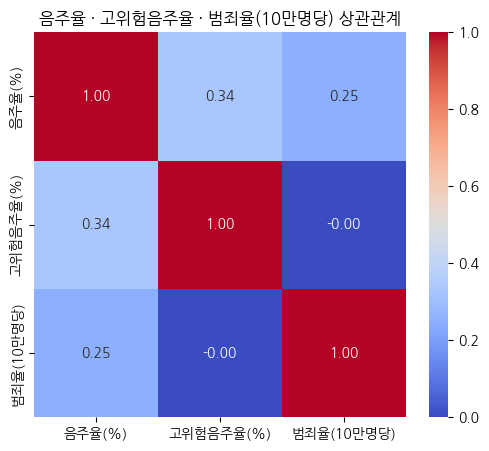

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["음주율(%)", "고위험음주율(%)", "범죄율(10만명당)"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("음주율 · 고위험음주율 · 범죄율(10만명당) 상관관계")
plt.show()



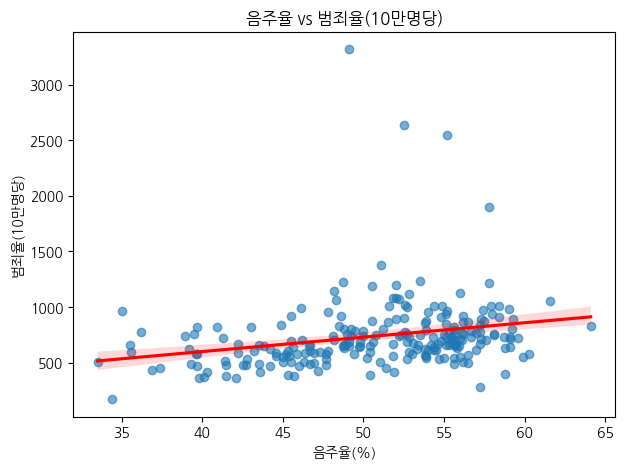

In [ ]:
# ---- (2) 음주율 vs 범죄율 회귀그래프 ----
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="음주율(%)", y="범죄율(10만명당)",
            scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("음주율 vs 범죄율(10만명당)")
plt.show()


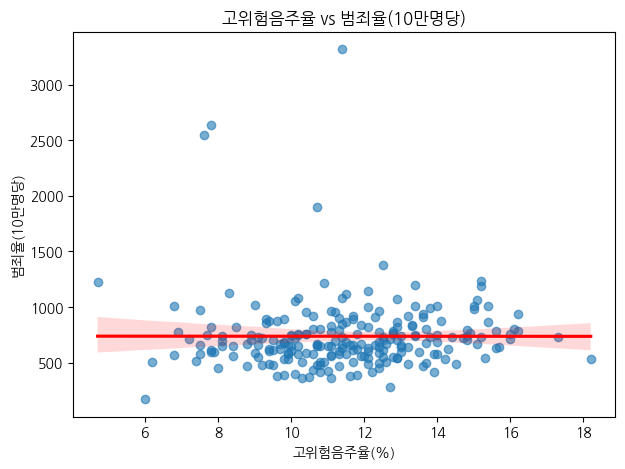

In [ ]:
# ---- (3) 고위험 음주율 vs 범죄율 회귀그래프 ----
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="고위험음주율(%)", y="범죄율(10만명당)",
            scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("고위험음주율 vs 범죄율(10만명당)")
plt.show()

/tmp/ipython-input-2234302217.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


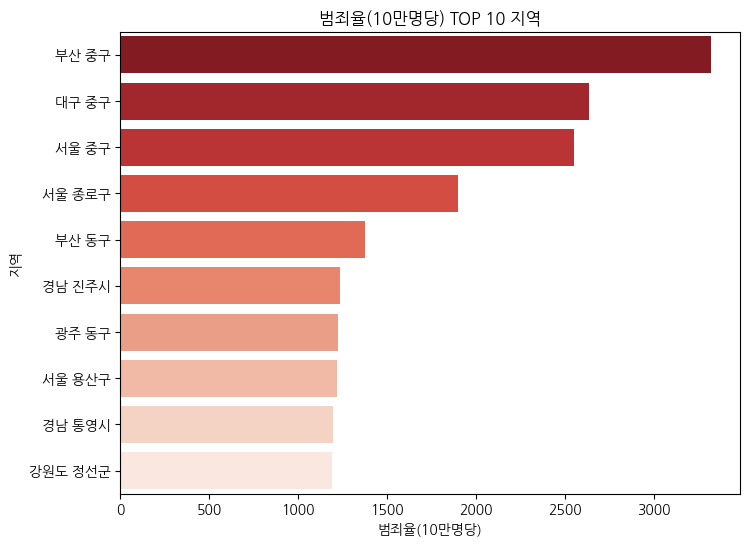

In [ ]:
top10 = df.sort_values("범죄율(10만명당)", ascending=False).head(10)
top10

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10,
    x="범죄율(10만명당)",
    y="지역",
    palette="Reds_r"
)

plt.title("범죄율(10만명당) TOP 10 지역")
plt.show()


/tmp/ipython-input-3128147248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


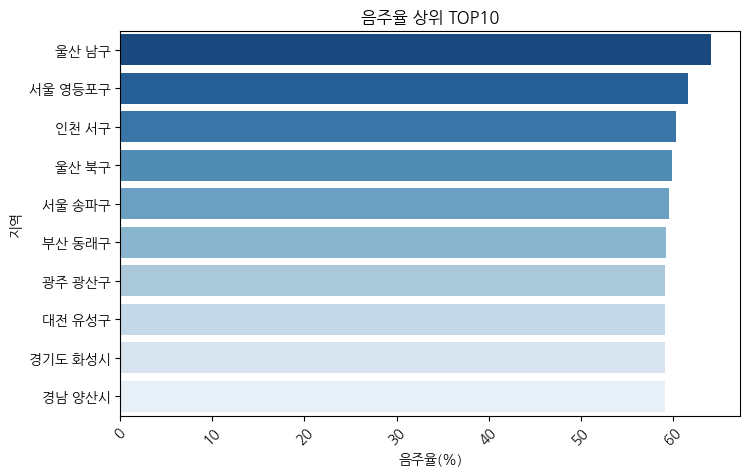

In [ ]:
top10_drinking = df.sort_values("음주율(%)", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10_drinking,
    x="음주율(%)",
    y="지역",
    palette="Blues_r"
)
plt.xticks(rotation=45)
plt.title("음주율 상위 TOP10")
plt.show()


/tmp/ipython-input-2100857908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


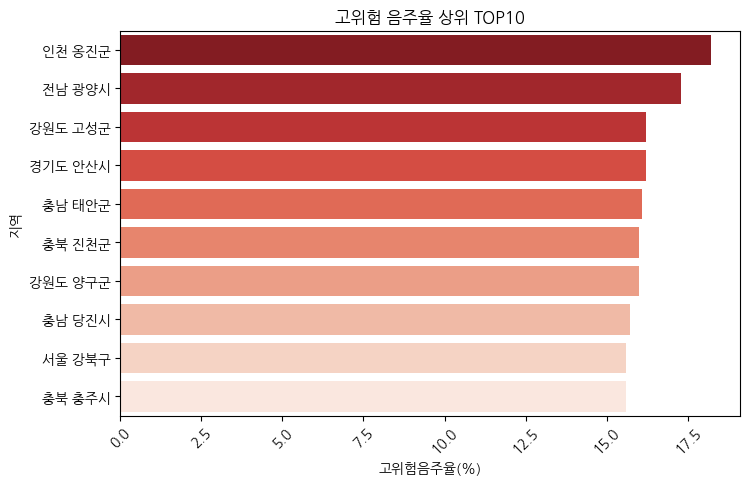

In [ ]:
top10_risk = df.sort_values("고위험음주율(%)", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10_risk,
    x="고위험음주율(%)",
    y="지역",
    palette="Reds_r"
)
plt.xticks(rotation=45)
plt.title("고위험 음주율 상위 TOP10")
plt.show()
